In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "Student_ID": [f"S{i}" for i in range(1, 21)],
    "Student_Name": [
        "Aarav", "Diya", "Rohan", "Ananya", "Karthik",
        "Meera", "Arjun", "Sana", "Varun", "Isha",
        "Rahul", "Priya", "Vikram", "Neha", "Aditya",
        "Sneha", "Manav", "Kavya", "Nikhil", "Pooja"
    ],
    "Gender": [
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female",
        "Male", "Female", "Male", "Female", "Male",
        "Female", "Male", "Female", "Male", "Female"
    ],
    "Class": [
        "A", "A", "B", "A", "C",
        "B", "B", "A", "C", "B",
        "A", "C", "B", "A", "C",
        "B", "C", "A", "B", "C"
    ],
    "Attendance": [
        85, 92, 70, 88, 60,
        95, 75, 90, 65, 82,
        78, 89, 73, 86, 68,
        91, 62, 80, 76, 87
    ],
    "Study_Hours": [
        5, 6, 3, 7, 2,
        6, 4, 7, 3, 5,
        4, 6, 4, 5, 3,
        7, 2, 5, 4, 6
    ],
    "Math_Score": [
        85, 90, 70, 95, 60,
        88, 76, 92, 67, 81,
        73, 89, 77, 84, 69,
        91, 62, 80, 75, 87
    ],
    "Science_Score": [
        80, 91, 65, 92, 58,
        85, 78, 90, 70, 82,
        75, 88, 79, 83, 68,
        89, 60, 78, 74, 86
    ],
    "English_Score": [
        82, 89, 68, 94, 57,
        87, 75, 91, 72, 84,
        76, 90, 80, 85, 70,
        92, 61, 81, 77, 88
    ]
}

df = pd.DataFrame(data)

# Display first rows
df.head()

,Student_ID,Student_Name,Gender,Class,Attendance,Study_Hours,Math_Score,Science_Score,English_Score
0,S1,Aarav,Male,A,85,5,85,80,82
1,S2,Diya,Female,A,92,6,90,91,89
2,S3,Rohan,Male,B,70,3,70,65,68
3,S4,Ananya,Female,A,88,7,95,92,94
4,S5,Karthik,Male,C,60,2,60,58,57


In [3]:
print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

# Remove duplicates and missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df.head()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Student_ID     20 non-null     str  
 1   Student_Name   20 non-null     str  
 2   Gender         20 non-null     str  
 3   Class          20 non-null     str  
 4   Attendance     20 non-null     int64
 5   Study_Hours    20 non-null     int64
 6   Math_Score     20 non-null     int64
 7   Science_Score  20 non-null     int64
 8   English_Score  20 non-null     int64
dtypes: int64(5), str(4)
memory usage: 1.5 KB
None

Missing Values:
Student_ID       0
Student_Name     0
Gender           0
Class            0
Attendance       0
Study_Hours      0
Math_Score       0
Science_Score    0
English_Score    0
dtype: int64

Duplicate Values:
0


,Student_ID,Student_Name,Gender,Class,Attendance,Study_Hours,Math_Score,Science_Score,English_Score
0,S1,Aarav,Male,A,85,5,85,80,82
1,S2,Diya,Female,A,92,6,90,91,89
2,S3,Rohan,Male,B,70,3,70,65,68
3,S4,Ananya,Female,A,88,7,95,92,94
4,S5,Karthik,Male,C,60,2,60,58,57


In [4]:
df["Total_Score"] = df[["Math_Score", "Science_Score", "English_Score"]].sum(axis=1)
df["Average_Score"] = df["Total_Score"] / 3

def assign_grade(avg):
    if avg >= 85:
        return "A"
    elif avg >= 70:
        return "B"
    elif avg >= 55:
        return "C"
    else:
        return "D"

df["Grade"] = df["Average_Score"].apply(assign_grade)

df.head()

,Student_ID,Student_Name,Gender,Class,Attendance,Study_Hours,Math_Score,Science_Score,English_Score,Total_Score,Average_Score,Grade
0,S1,Aarav,Male,A,85,5,85,80,82,247,82.333333,B
1,S2,Diya,Female,A,92,6,90,91,89,270,90.000000,A
2,S3,Rohan,Male,B,70,3,70,65,68,203,67.666667,C
3,S4,Ananya,Female,A,88,7,95,92,94,281,93.666667,A
4,S5,Karthik,Male,C,60,2,60,58,57,175,58.333333,C


In [5]:
print("Overall Statistics:")
display(df.describe())

print("Average Scores by Subject:")
subject_average = df[["Math_Score", "Science_Score", "English_Score"]].mean()
display(subject_average)

print("Grade Count:")
display(df["Grade"].value_counts())

print("Top 5 Students:")
display(df.sort_values(by="Average_Score", ascending=False).head())

print("Low Performing Students:")
display(df.sort_values(by="Average_Score", ascending=True).head())

Overall Statistics:


,Attendance,Study_Hours,Math_Score,Science_Score,English_Score,Total_Score,Average_Score
count,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000
mean,79.600000,4.700000,79.55000,78.550000,79.950000,238.050000,79.350000
std,10.594934,1.592747,10.34904,10.169485,10.384579,30.704834,10.234945
min,60.000000,2.000000,60.00000,58.000000,57.000000,175.000000,58.333333
25%,72.250000,3.750000,72.25000,73.000000,74.250000,220.250000,73.416667
50%,81.000000,5.000000,80.50000,79.500000,81.500000,243.000000,81.000000
75%,88.250000,6.000000,88.25000,86.500000,88.250000,262.500000,87.500000
max,95.000000,7.000000,95.00000,92.000000,94.000000,281.000000,93.666667


Average Scores by Subject:


Math_Score       79.55
Science_Score    78.55
English_Score    79.95
dtype: float64

Grade Count:


Grade
B    8
A    7
C    5
Name: count, dtype: int64

Top 5 Students:


,Student_ID,Student_Name,Gender,Class,Attendance,Study_Hours,Math_Score,Science_Score,English_Score,Total_Score,Average_Score,Grade
3,S4,Ananya,Female,A,88,7,95,92,94,281,93.666667,A
7,S8,Sana,Female,A,90,7,92,90,91,273,91.000000,A
15,S16,Sneha,Female,B,91,7,91,89,92,272,90.666667,A
1,S2,Diya,Female,A,92,6,90,91,89,270,90.000000,A
11,S12,Priya,Female,C,89,6,89,88,90,267,89.000000,A


Low Performing Students:


,Student_ID,Student_Name,Gender,Class,Attendance,Study_Hours,Math_Score,Science_Score,English_Score,Total_Score,Average_Score,Grade
4,S5,Karthik,Male,C,60,2,60,58,57,175,58.333333,C
16,S17,Manav,Male,C,62,2,62,60,61,183,61.000000,C
2,S3,Rohan,Male,B,70,3,70,65,68,203,67.666667,C
14,S15,Aditya,Male,C,68,3,69,68,70,207,69.000000,C
8,S9,Varun,Male,C,65,3,67,70,72,209,69.666667,C


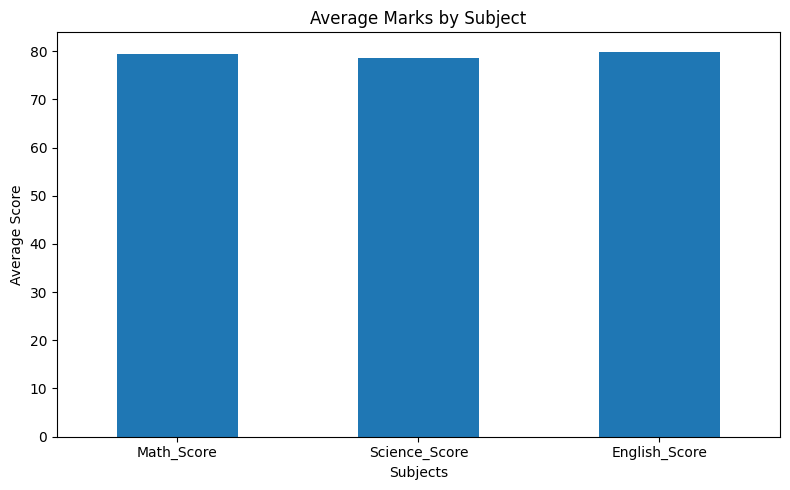

In [6]:
plt.figure(figsize=(8,5))
subject_average.plot(kind="bar")
plt.title("Average Marks by Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("subject_average.png")
plt.show()

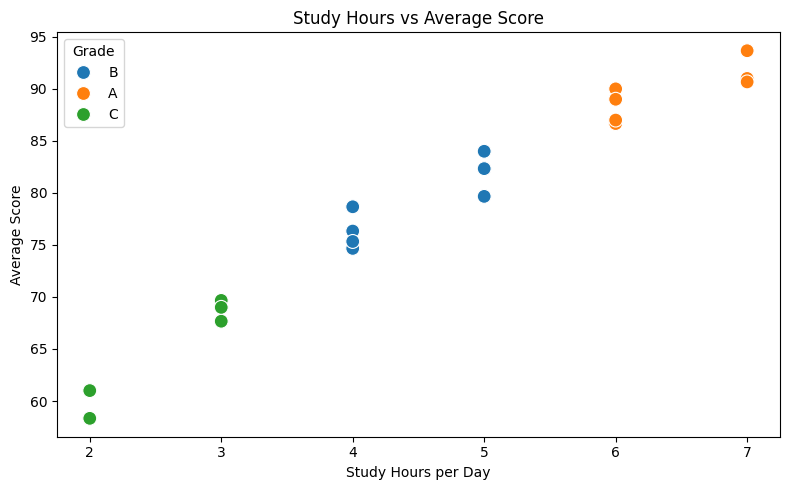

In [7]:

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Study_Hours", y="Average_Score", hue="Grade", s=100)
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("study_hours_vs_performance.png")
plt.show()

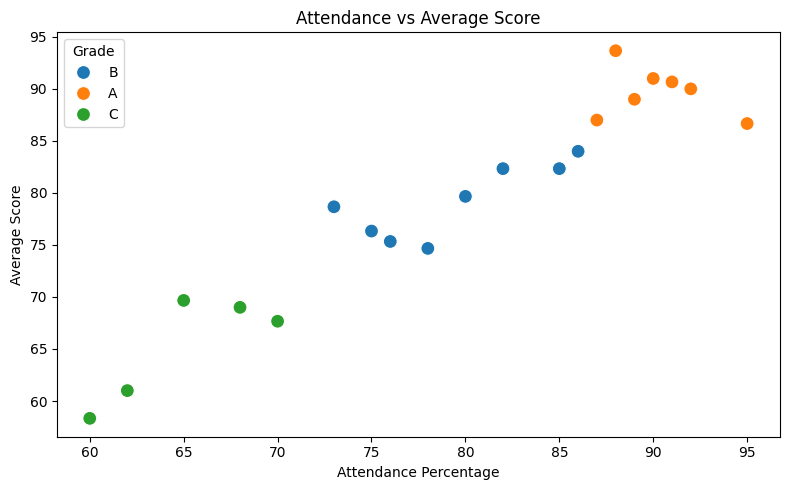

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Attendance", y="Average_Score", hue="Grade", s=100)
plt.title("Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("attendance_vs_performance.png")
plt.show()

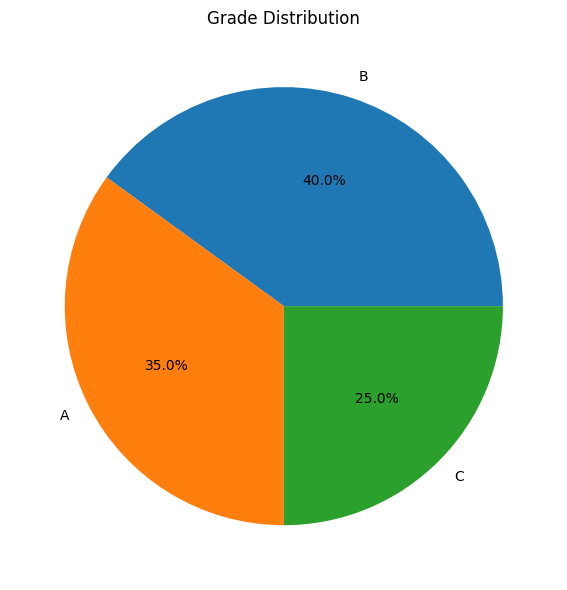

In [9]:
plt.figure(figsize=(6,6))
df["Grade"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Grade Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig("grade_distribution.png")
plt.show()

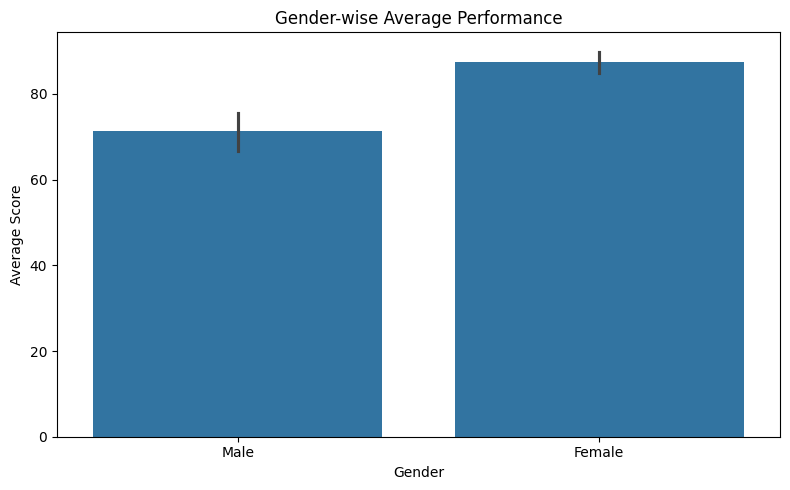

In [10]:

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Gender", y="Average_Score")
plt.title("Gender-wise Average Performance")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("gender_wise_performance.png")
plt.show()

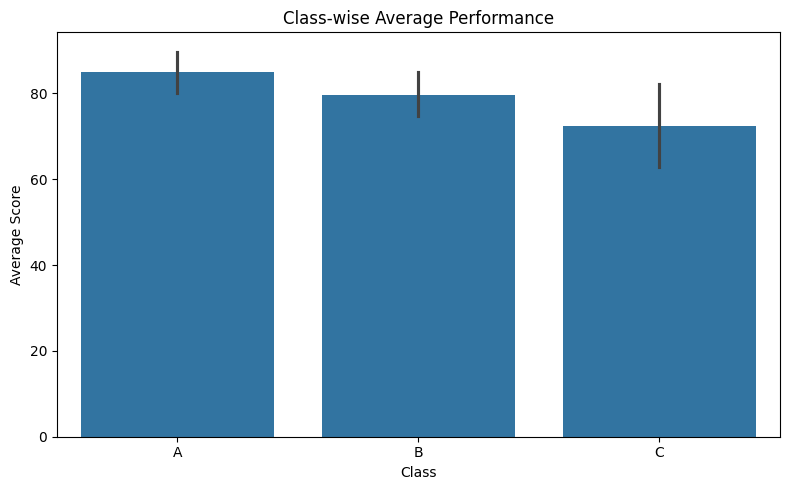

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Class", y="Average_Score")
plt.title("Class-wise Average Performance")
plt.xlabel("Class")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("class_wise_performance.png")
plt.show()

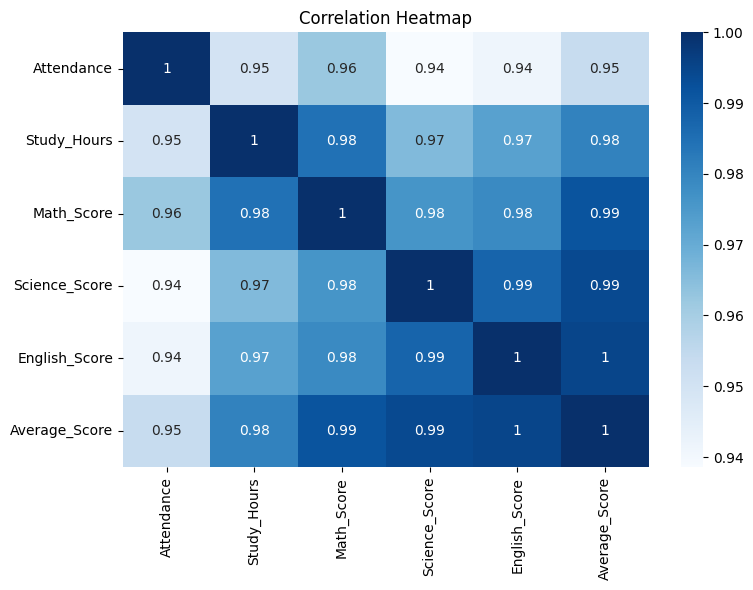

In [12]:
correlation = df[[
    "Attendance", "Study_Hours", "Math_Score",
    "Science_Score", "English_Score", "Average_Score"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

## Insights & Recommendations

## Insights

1. Students who study more than 5–6 hours daily score higher marks.
2. Students with attendance above 80% perform better.
3. Math scores are lower compared to Science and English.
4. Most students are in Grade B and C categories.
5. Low study hours and low attendance lead to poor performance.
6. Regular study and good attendance improve results.

## Recommendations

1. Maintain attendance above 85%.
2. Study at least 5–6 hours daily.
3. Focus more on Mathematics.
4. Provide support to low-performing students.
5. Follow a consistent study routine.